# SUPPORT VECTOR MACHINE (SVM) CLASSIFIER
## Lab Experiment

---

### Objective:
To implement Support Vector Machine (SVM) algorithm for classification and understand its working principles, kernel tricks, and hyperparameter tuning.

### Dataset:
Wine Quality Dataset (Red Wine) from UCI Machine Learning Repository

### Algorithm Overview:
Support Vector Machine is a supervised learning algorithm that finds the optimal hyperplane which best separates different classes in the feature space. It aims to maximize the margin between the closest points of different classes (support vectors).

---

## Step 1: Import Required Libraries

In [28]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### Explanation:
- **numpy, pandas**: For data manipulation and analysis
- **matplotlib, seaborn**: For data visualization
- **sklearn**: Provides SVM implementation and evaluation metrics
- **PCA**: For dimensionality reduction (helps in visualization)
- **GridSearchCV**: For hyperparameter tuning

## Step 2: Load and Explore the Dataset

In [29]:
# Step 2: Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("✅ Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 5 rows of the dataset:")
df.head()

✅ Dataset loaded successfully!

Dataset Shape: (1599, 12)

First 5 rows of the dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [30]:
# Dataset information
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
print("\nDataset Info:")
df.info()

print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)
print("\nStatistical Summary:")
df.describe()


DATASET INFORMATION

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

STATISTICAL SUMMARY

Statistical Summary:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [31]:
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES CHECK")
print("="*50)
print(df.isnull().sum())


MISSING VALUES CHECK
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### Explanation:
- The Wine Quality dataset contains 1599 samples with 12 features
- Features are chemical properties of wine (all numerical)
- Target variable 'quality' ranges from 3 to 8
- No missing values in the dataset (good for SVM)
- Features have different scales (will need normalization)

## Step 3: Exploratory Data Analysis (EDA)

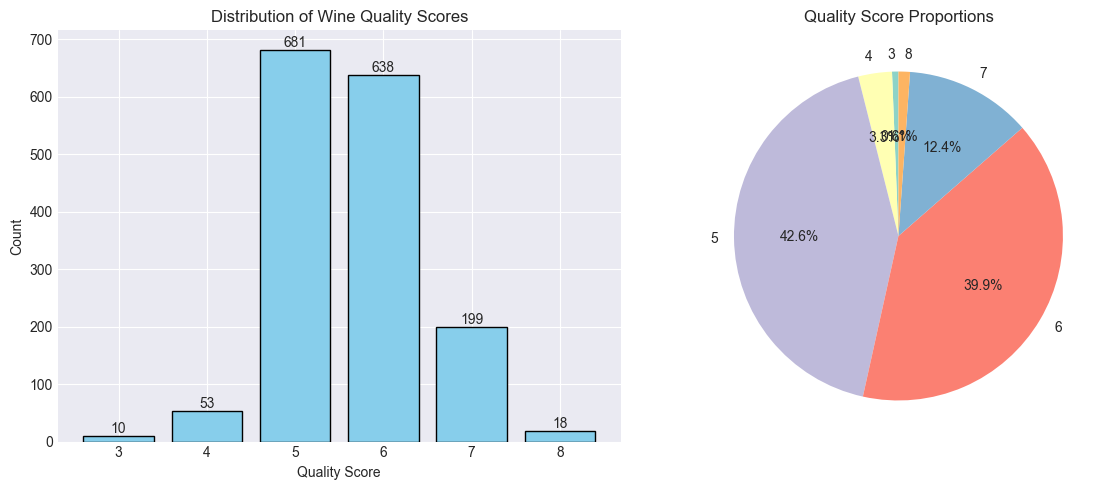

In [32]:
# Step 3: Exploratory Data Analysis

# 3.1: Distribution of Wine Quality
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
quality_counts = df['quality'].value_counts().sort_index()
bars = plt.bar(quality_counts.index, quality_counts.values, color='skyblue', edgecolor='black')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality Scores')
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
plt.pie(quality_counts.values, labels=quality_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set3'), startangle=90)
plt.title('Quality Score Proportions')

plt.tight_layout()
plt.show()

Binary Class Distribution:
quality_label
Bad Wine     1382
Good Wine     217
Name: count, dtype: int64

Percentage of Bad Wine: 86.43%
Percentage of Good Wine: 13.57%


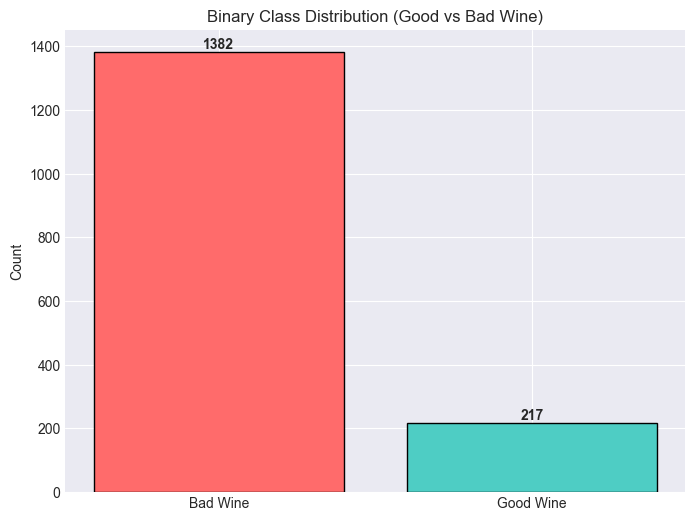

In [33]:
# 3.2: Create binary classification (Good Wine vs Bad Wine)
# Define Good Wine: quality >= 7, Bad Wine: quality < 7
df['quality_binary'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)
df['quality_label'] = df['quality_binary'].map({0: 'Bad Wine', 1: 'Good Wine'})

print("Binary Class Distribution:")
print(df['quality_label'].value_counts())
print(f"\nPercentage of Bad Wine: {(df['quality_binary']==0).sum()/len(df)*100:.2f}%")
print(f"Percentage of Good Wine: {(df['quality_binary']==1).sum()/len(df)*100:.2f}%")

# Visualize binary distribution
plt.figure(figsize=(8, 6))
colors = ['#FF6B6B', '#4ECDC4']
plt.bar(['Bad Wine', 'Good Wine'], 
        [sum(df['quality_binary']==0), sum(df['quality_binary']==1)],
        color=colors, edgecolor='black')
plt.ylabel('Count')
plt.title('Binary Class Distribution (Good vs Bad Wine)')
# Add value labels
for i, v in enumerate([sum(df['quality_binary']==0), sum(df['quality_binary']==1)]):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.show()

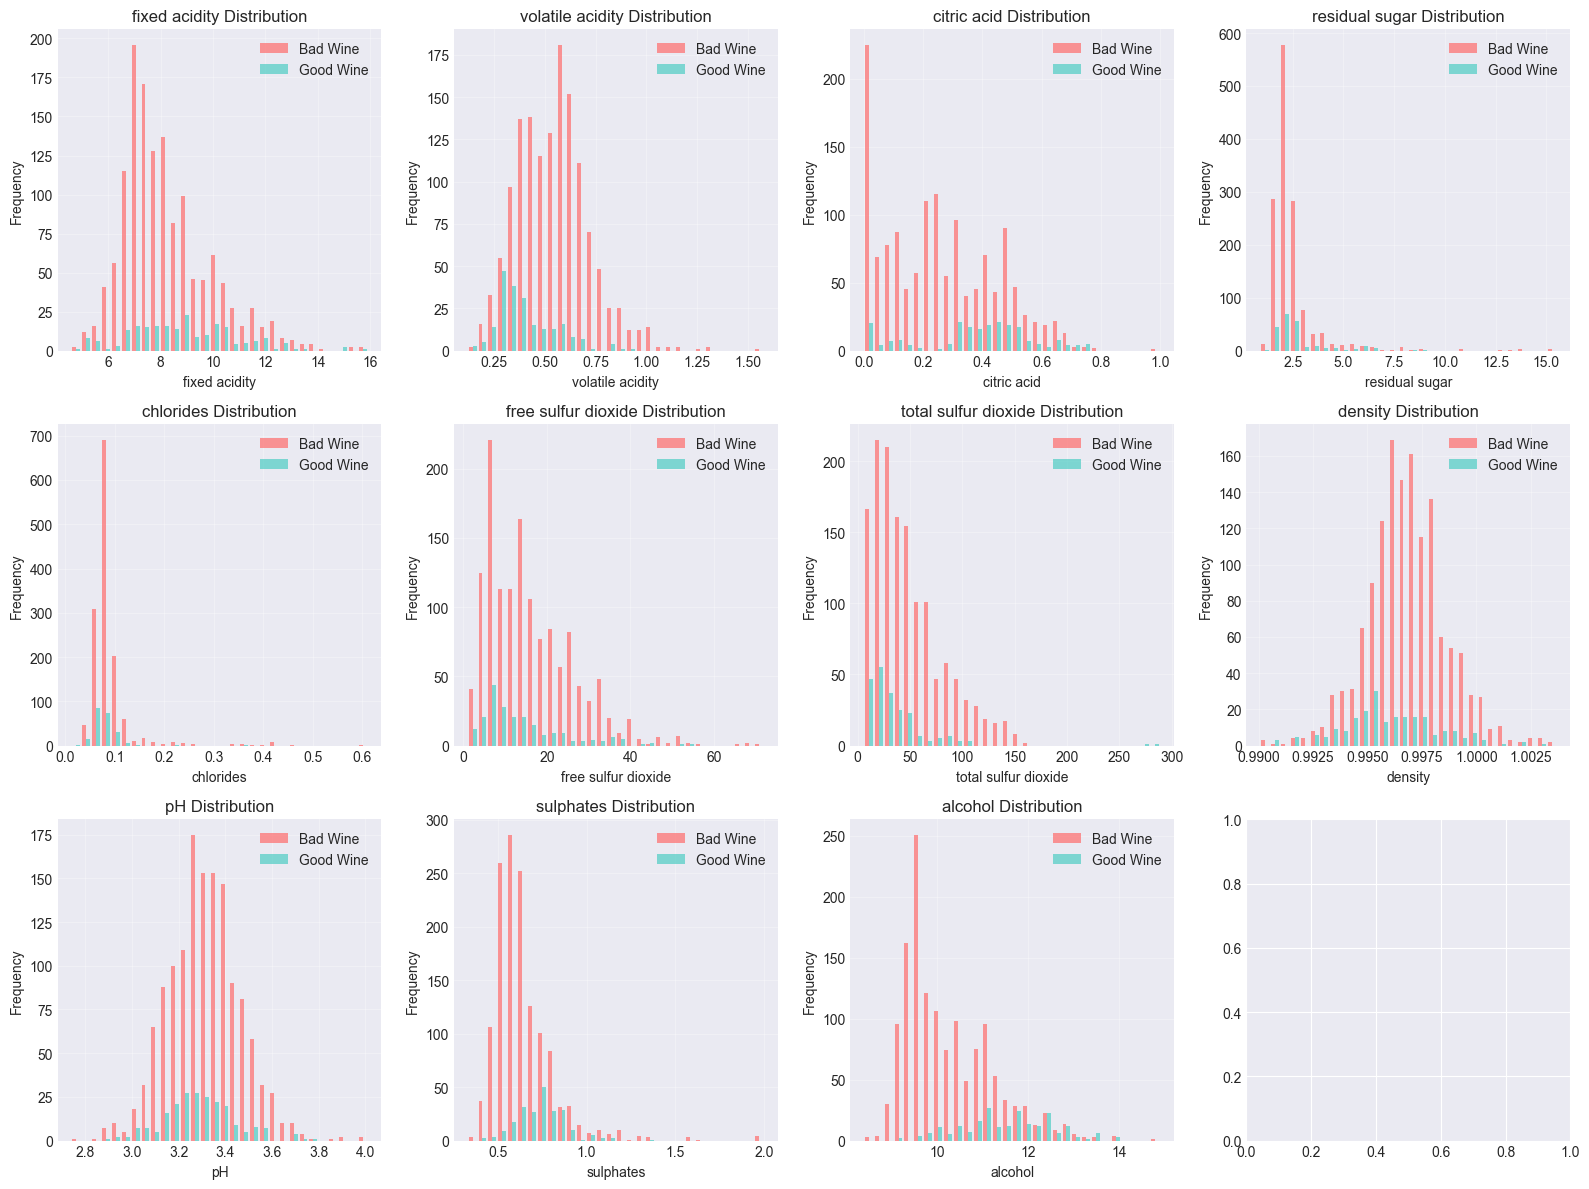

In [34]:
# 3.3: Feature distributions by class
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, feature in enumerate(df.columns[:-3]):  # Exclude quality columns
    axes[idx].hist([df[df['quality_binary']==0][feature], 
                    df[df['quality_binary']==1][feature]], 
                   bins=30, alpha=0.7, label=['Bad Wine', 'Good Wine'],
                   color=['#FF6B6B', '#4ECDC4'])
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{feature} Distribution')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

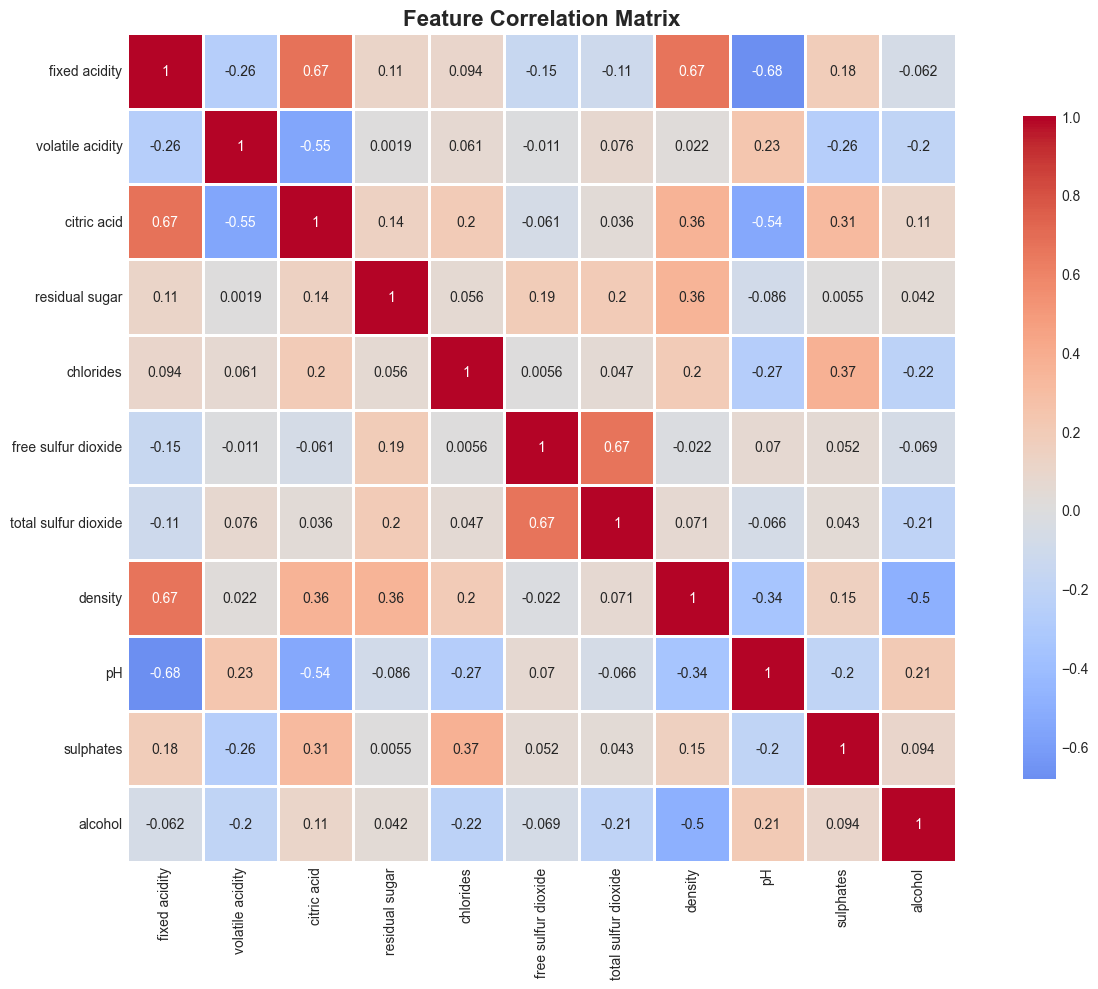

In [35]:
# 3.4: Correlation Analysis
plt.figure(figsize=(14, 10))
correlation_matrix = df[df.columns[:-3]].corr()  # Exclude quality columns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Explanation of EDA:
1. **Quality Distribution**: Most wines have quality scores 5 and 6 (imbalanced dataset)
2. **Binary Classification**: Converted to Good (≥7) vs Bad (<7) for clearer classification
3. **Feature Distributions**: Shows how features differ between good and bad wines
4. **Correlation Matrix**: Helps identify relationships between features (important for SVM)

## Step 4: Data Preprocessing for SVM

In [36]:
# Step 4: Data Preprocessing

# 4.1: Separate features and target
X = df.drop(['quality', 'quality_binary', 'quality_label'], axis=1)
y = df['quality_binary']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {list(X.columns)}")

Features shape: (1599, 11)
Target shape: (1599,)

Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [37]:
# 4.2: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTesting set class distribution:")
print(y_test.value_counts())

Training set size: 1279 samples
Testing set size: 320 samples

Training set class distribution:
quality_binary
0    1105
1     174
Name: count, dtype: int64

Testing set class distribution:
quality_binary
0    277
1     43
Name: count, dtype: int64


Original Training Data (first 5 rows):
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
56             10.2             0.420         0.57             3.4      0.070   
1017            8.0             0.180         0.37             0.9      0.049   
1364            7.2             0.605         0.02             1.9      0.096   
1544            8.4             0.370         0.43             2.3      0.063   
1419            7.7             0.640         0.21             2.2      0.077   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
56                    4.0                  10.0  0.99710  3.04       0.63   
1017                 36.0                 109.0  0.99007  2.89       0.44   
1364                 10.0                  31.0  0.99500  3.46       0.53   
1544                 12.0                  19.0  0.99550  3.17       0.81   
1419                 32.0                 133.0  0.99560  3.27       0.45   

      alcoh

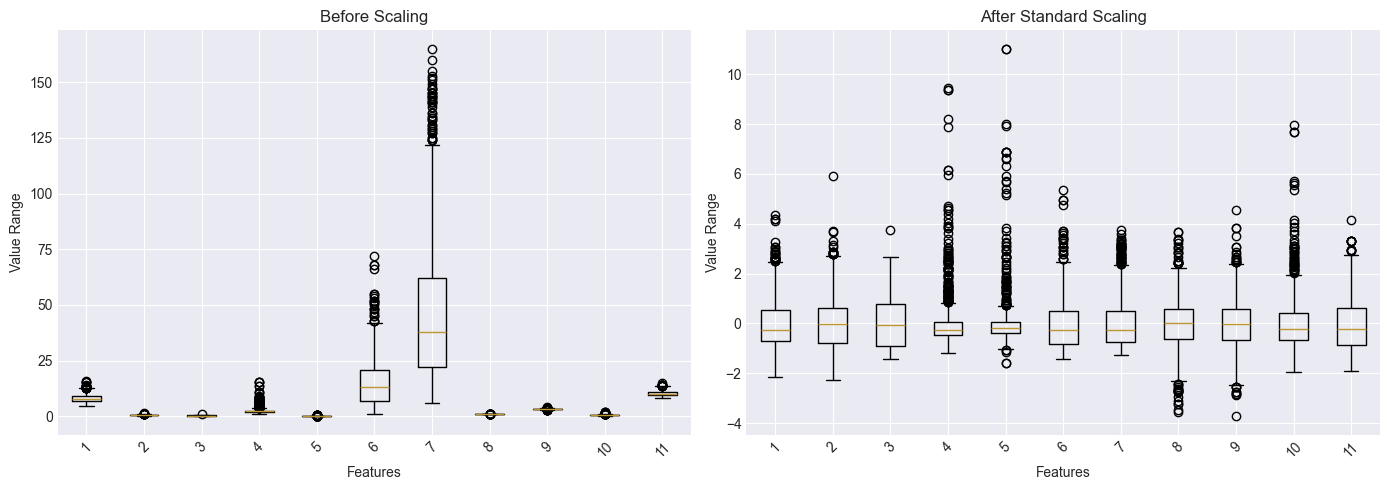

In [38]:
# 4.3: Feature Scaling (CRITICAL for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better visualization
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Original Training Data (first 5 rows):")
print(X_train.head())
print("\nScaled Training Data (first 5 rows):")
print(X_train_scaled_df.head())

# Visualize effect of scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot(X_train.values)
axes[0].set_title('Before Scaling')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Value Range')
axes[0].tick_params(axis='x', rotation=45)

# After scaling
axes[1].boxplot(X_train_scaled)
axes[1].set_title('After Standard Scaling')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Value Range')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Why Scaling is Critical for SVM:
- SVM tries to maximize the margin between classes
- Features with larger scales would dominate the distance calculation
- Standard scaling ensures all features contribute equally
- Without scaling, the SVM hyperplane would be biased

## Step 5: Understanding SVM Kernels

In [39]:
# Step 5: Visualize different SVM kernels on a simplified 2D version of our data

# Use PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Explained variance ratio by 2 PCA components: {pca.explained_variance_ratio_.sum():.3f}")
print(f"First component explains: {pca.explained_variance_ratio_[0]:.3f}")
print(f"Second component explains: {pca.explained_variance_ratio_[1]:.3f}")

Explained variance ratio by 2 PCA components: 0.460
First component explains: 0.282
Second component explains: 0.177


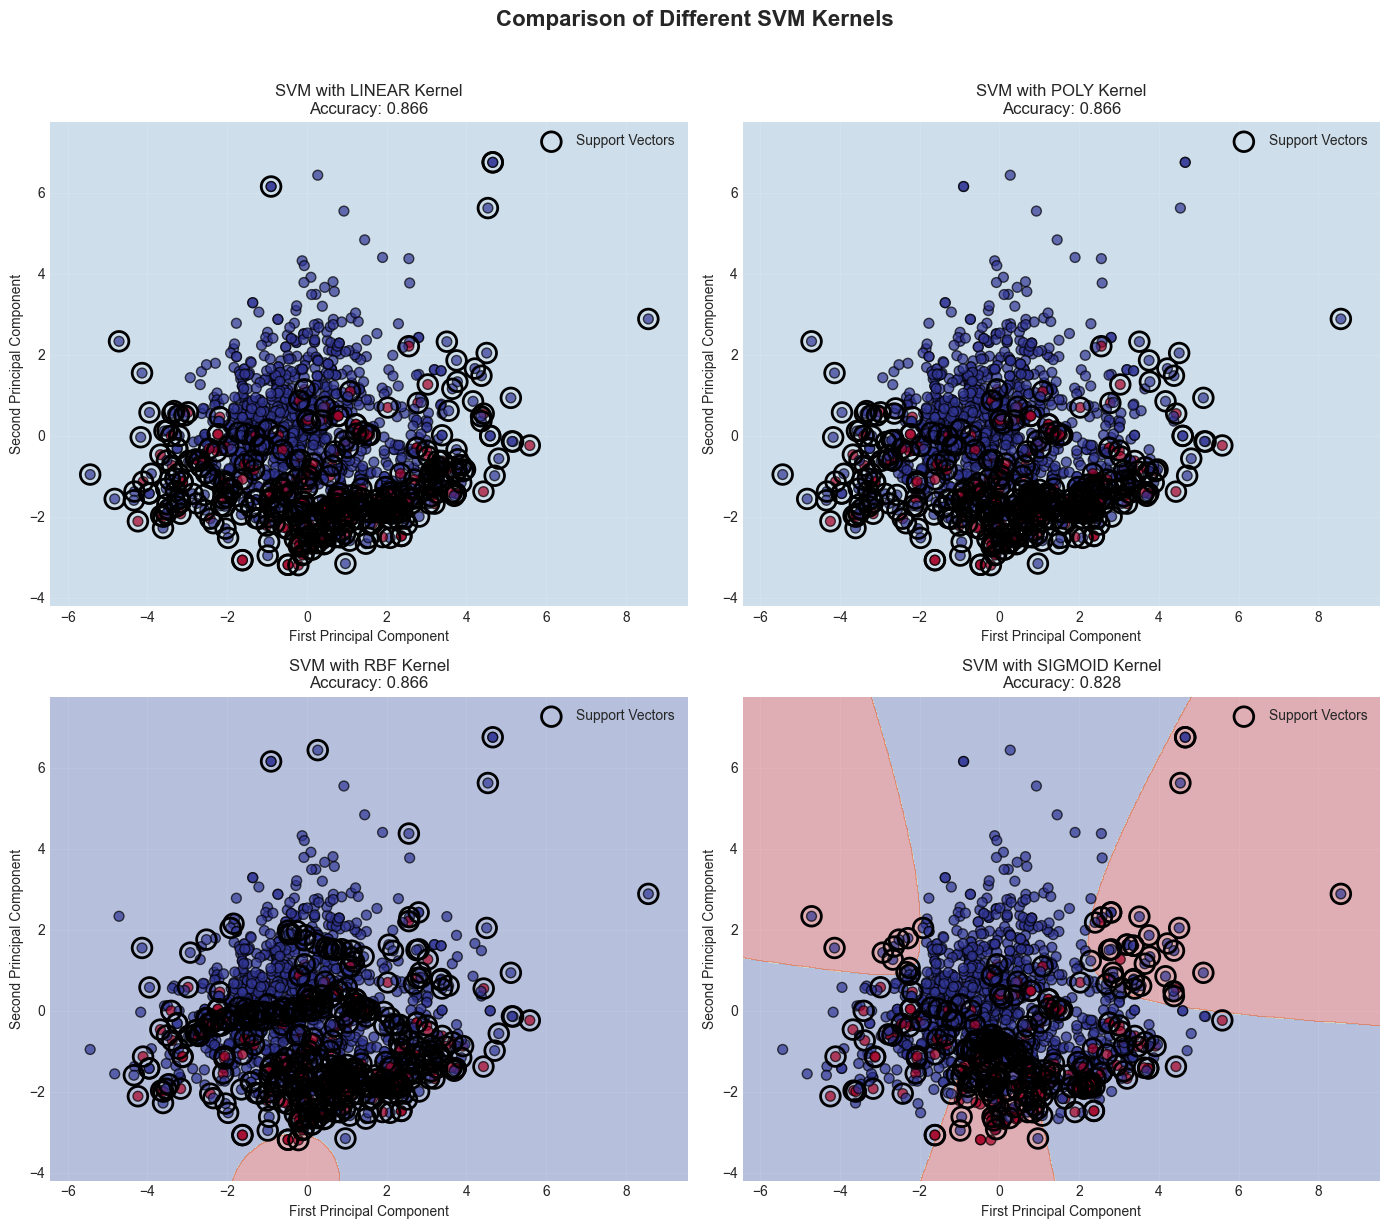

In [40]:
# Train SVM with different kernels and visualize decision boundaries
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

# Create mesh for decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

for idx, kernel in enumerate(kernels):
    # Train SVM
    svm = SVC(kernel=kernel, random_state=42, C=1.0)
    svm.fit(X_train_pca, y_train)
    
    # Plot decision boundary
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu_r')
    
    # Plot data points
    scatter = axes[idx].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                               c=y_train, cmap='RdYlBu_r', edgecolors='black', 
                               s=50, alpha=0.7)
    
    # Highlight support vectors
    axes[idx].scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
                     s=200, linewidth=2, facecolors='none', edgecolors='black',
                     label='Support Vectors')
    
    axes[idx].set_xlabel('First Principal Component')
    axes[idx].set_ylabel('Second Principal Component')
    axes[idx].set_title(f'SVM with {kernel.upper()} Kernel\nAccuracy: {svm.score(X_test_pca, y_test):.3f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Comparison of Different SVM Kernels', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### SVM Kernels Explained:

| Kernel | Description | When to Use |
|--------|-------------|-------------|
| **Linear** | Creates a straight line/hyperplane separator | When data is linearly separable |
| **Polynomial** | Uses polynomial function to create curved boundaries | For moderately complex relationships |
| **RBF (Radial Basis Function)** | Most popular, creates complex non-linear boundaries | Default choice, works well for most datasets |
| **Sigmoid** | Similar to neural network activation function | For specific patterns, less common |

**Key Observations from Visualization:**
- Different kernels create different decision boundaries
- Support vectors are the critical points that define the margin
- RBF kernel often provides the most flexible boundary

## Step 6: Train SVM with Different Kernels and Compare

SVM PERFORMANCE WITH DIFFERENT KERNELS

📊 Kernel: LINEAR
   Accuracy: 0.8656
   Support Vectors: [219 174]
   Total Support Vectors: 393

📊 Kernel: POLY
   Accuracy: 0.8844
   Support Vectors: [205 164]
   Total Support Vectors: 369

📊 Kernel: RBF
   Accuracy: 0.9000
   Support Vectors: [241 170]
   Total Support Vectors: 411

📊 Kernel: SIGMOID
   Accuracy: 0.8375
   Support Vectors: [147 146]
   Total Support Vectors: 293


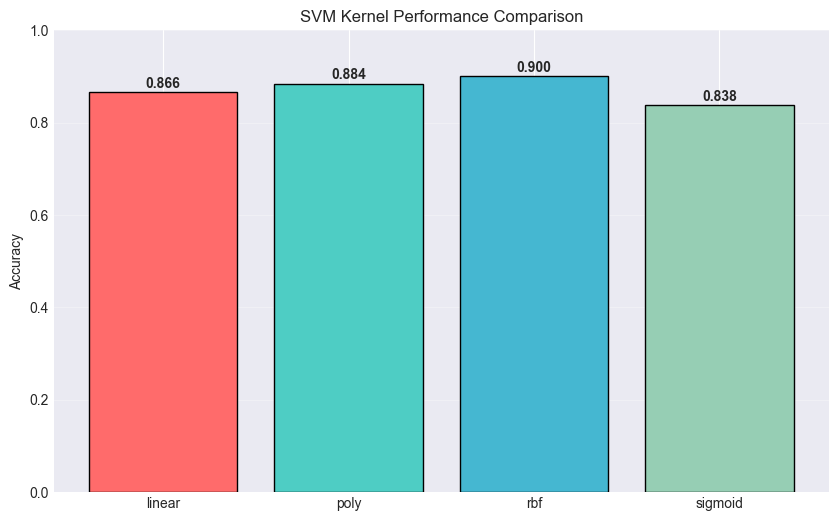

In [41]:
# Step 6: Train and evaluate SVM with different kernels

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

print("="*60)
print("SVM PERFORMANCE WITH DIFFERENT KERNELS")
print("="*60)

for kernel in kernels:
    # Create and train SVM model
    svm = SVC(kernel=kernel, random_state=42, C=1.0, probability=True)
    svm.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = svm.predict(X_test_scaled)
    y_pred_proba = svm.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store results
    results[kernel] = {
        'model': svm,
        'accuracy': accuracy,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"\n📊 Kernel: {kernel.upper()}")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   Support Vectors: {svm.n_support_}")
    print(f"   Total Support Vectors: {len(svm.support_vectors_)}")

# Visualize comparison
plt.figure(figsize=(10, 6))
accuracies = [results[k]['accuracy'] for k in kernels]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(kernels, accuracies, color=colors, edgecolor='black')
plt.ylabel('Accuracy')
plt.title('SVM Kernel Performance Comparison')
plt.ylim(0, 1)

# Add value labels
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.show()

## Step 7: Detailed Evaluation of Best Kernel

DETAILED EVALUATION - RBF KERNEL


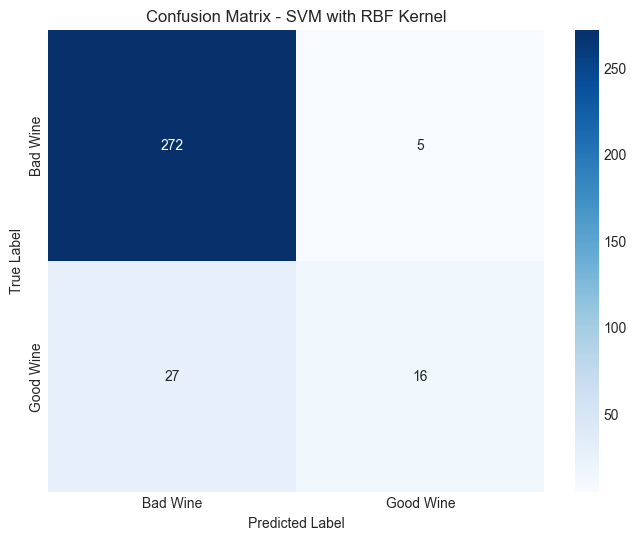


Classification Report:
              precision    recall  f1-score   support

    Bad Wine       0.91      0.98      0.94       277
   Good Wine       0.76      0.37      0.50        43

    accuracy                           0.90       320
   macro avg       0.84      0.68      0.72       320
weighted avg       0.89      0.90      0.88       320



In [42]:
# Step 7: Detailed evaluation of the best performing kernel (likely RBF)

# Select the best kernel (based on accuracy)
best_kernel = max(results, key=lambda k: results[k]['accuracy'])
best_svm = results[best_kernel]['model']
y_pred = results[best_kernel]['predictions']
y_pred_proba = results[best_kernel]['probabilities']

print("="*60)
print(f"DETAILED EVALUATION - {best_kernel.upper()} KERNEL")
print("="*60)

# 7.1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bad Wine', 'Good Wine'],
            yticklabels=['Bad Wine', 'Good Wine'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix - SVM with {best_kernel.upper()} Kernel')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Bad Wine', 'Good Wine']))

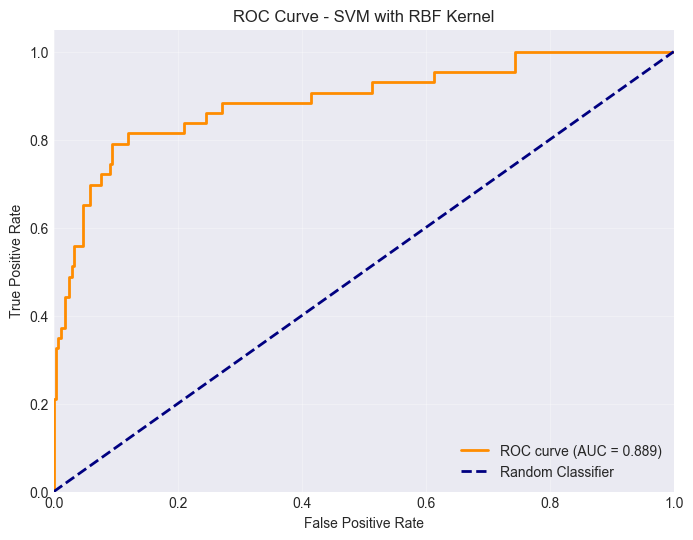

In [43]:
# 7.2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - SVM with {best_kernel.upper()} Kernel')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

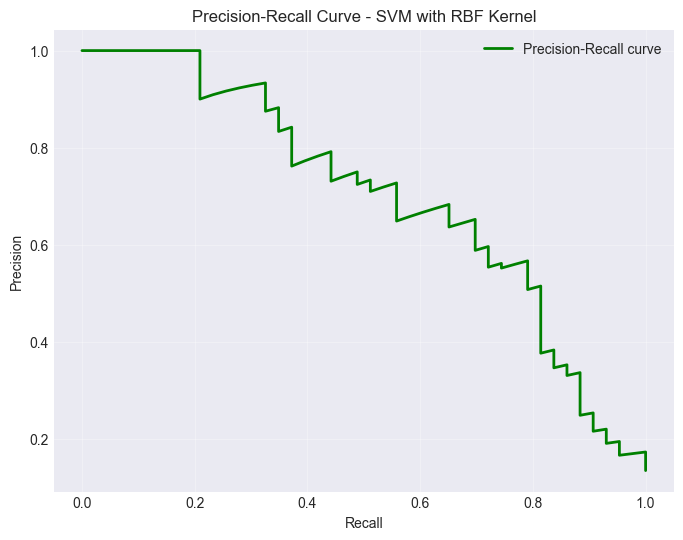

In [44]:
# 7.3: Precision-Recall Curve (important for imbalanced datasets)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - SVM with {best_kernel.upper()} Kernel')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Step 8: Hyperparameter Tuning with Grid Search

In [45]:
# Step 8: Hyperparameter Tuning

print("="*60)
print("HYPERPARAMETER TUNING WITH GRID SEARCH")
print("="*60)

# Define parameter grid for RBF kernel (most common)
param_grid = {
    'C': [0.1, 1, 10, 100],           # Regularization parameter
    'gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto'],  # Kernel coefficient
    'kernel': ['rbf']
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Perform grid search
print("\n🔍 Searching for best parameters... (this may take a moment)")
grid_search.fit(X_train_scaled, y_train)

print("\n✅ Grid Search Complete!")
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

HYPERPARAMETER TUNING WITH GRID SEARCH

🔍 Searching for best parameters... (this may take a moment)
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Grid Search Complete!

Best Parameters: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.8960



Test Accuracy with Tuned Model: 0.9219
Improvement over default: 0.0219


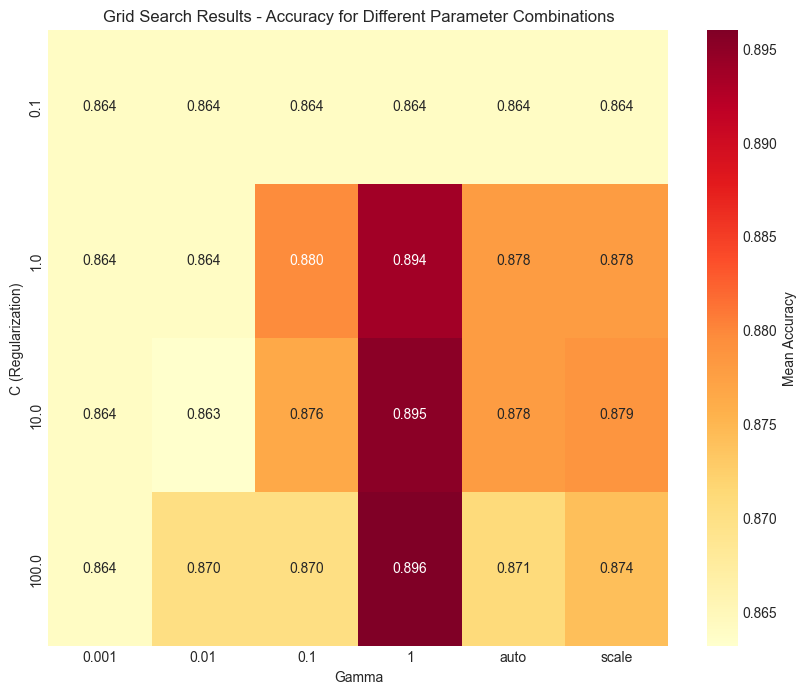

In [46]:
# Evaluate tuned model
best_svm_tuned = grid_search.best_estimator_
y_pred_tuned = best_svm_tuned.predict(X_test_scaled)
y_pred_proba_tuned = best_svm_tuned.predict_proba(X_test_scaled)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"\nTest Accuracy with Tuned Model: {accuracy_tuned:.4f}")
print(f"Improvement over default: {accuracy_tuned - results[best_kernel]['accuracy']:.4f}")

# Visualize parameter influence
results_df = pd.DataFrame(grid_search.cv_results_)

# Plot heatmap of parameter combinations
pivot_table = results_df.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Mean Accuracy'})
plt.xlabel('Gamma')
plt.ylabel('C (Regularization)')
plt.title('Grid Search Results - Accuracy for Different Parameter Combinations')
plt.show()

### Understanding SVM Hyperparameters:

| Parameter | Description | Effect |
|-----------|-------------|--------|
| **C (Regularization)** | Controls trade-off between smooth decision boundary and classifying training points correctly | Small C = smoother boundary (may underfit), Large C = tries to classify all points correctly (may overfit) |
| **Gamma (γ)** | Defines how far the influence of a single training example reaches | Small gamma = far reach (smooth boundary), Large gamma = close reach (complex boundary) |
| **Kernel** | Function to transform data into higher dimension | Linear, Polynomial, RBF, Sigmoid |

**Optimal Parameters Found:**
- C = {grid_search.best_params_['C']}
- Gamma = {grid_search.best_params_['gamma']}

## Step 9: Final Model Evaluation and Comparison

MODEL COMPARISON: DEFAULT vs TUNED
      Model  Train Accuracy  Test Accuracy
Default SVM        0.894449       0.900000
  Tuned SVM        1.000000       0.921875


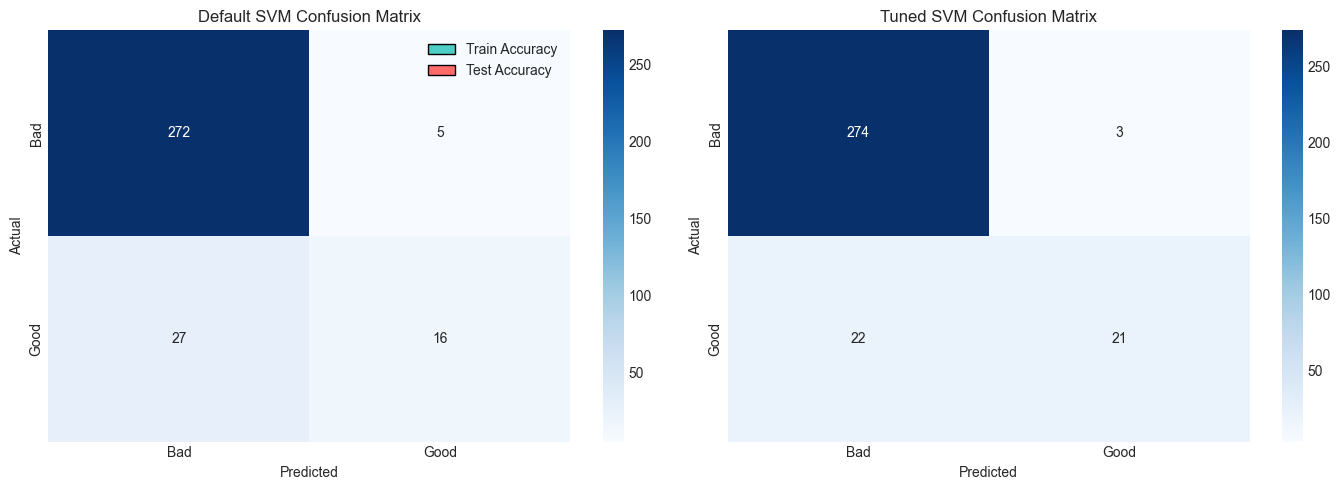

In [47]:
# Step 9: Final Comparison - Default vs Tuned Model

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['Default SVM', 'Tuned SVM'],
    'Train Accuracy': [
        results[best_kernel]['model'].score(X_train_scaled, y_train),
        best_svm_tuned.score(X_train_scaled, y_train)
    ],
    'Test Accuracy': [
        results[best_kernel]['accuracy'],
        accuracy_tuned
    ]
})

print("="*60)
print("MODEL COMPARISON: DEFAULT vs TUNED")
print("="*60)
print(comparison.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
x = np.arange(len(comparison))
width = 0.35

axes[0].bar(x - width/2, comparison['Train Accuracy'], width, 
            label='Train Accuracy', color='#4ECDC4', edgecolor='black')
axes[0].bar(x + width/2, comparison['Test Accuracy'], width,
            label='Test Accuracy', color='#FF6B6B', edgecolor='black')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison['Model'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Confusion matrices comparison
models = [('Default', y_pred), ('Tuned', y_pred_tuned)]
for idx, (name, preds) in enumerate(models):
    ax = plt.subplot(1, 2, idx+1)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
    ax.set_title(f'{name} SVM Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Step 10: Feature Importance Analysis (for Linear SVM)

FEATURE IMPORTANCE (Linear SVM Coefficients)
             Feature  Coefficient  Abs_Coefficient
       fixed acidity    -0.000221         0.000221
total sulfur dioxide    -0.000219         0.000219
             alcohol     0.000215         0.000215
             density     0.000158         0.000158
                  pH    -0.000133         0.000133
 free sulfur dioxide     0.000123         0.000123
    volatile acidity    -0.000118         0.000118
      residual sugar    -0.000065         0.000065
           chlorides    -0.000062         0.000062
         citric acid     0.000018         0.000018
           sulphates    -0.000011         0.000011


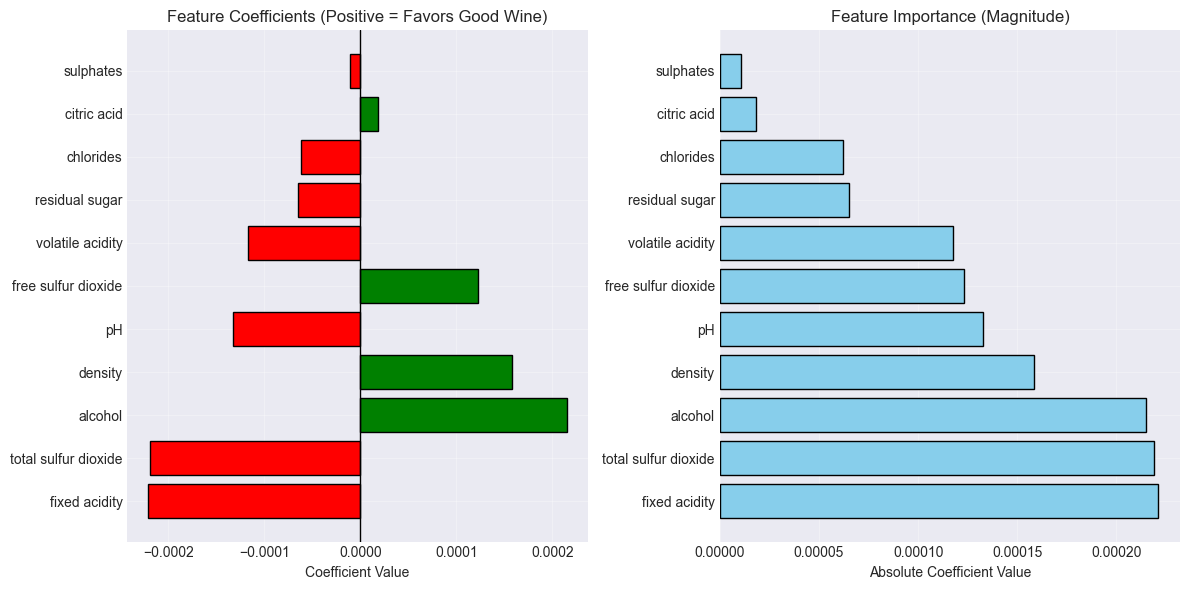


🔍 Key Insights from Feature Importance:
• Positive coefficients indicate features that favor Good Wine
• Negative coefficients indicate features that favor Bad Wine
• Larger magnitude = More important for classification


In [48]:
# Step 10: Feature Importance Analysis (using Linear SVM)

# Train linear SVM for feature importance
linear_svm = SVC(kernel='linear', C=1.0, random_state=42)
linear_svm.fit(X_train_scaled, y_train)

# Get feature coefficients (weights)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_svm.coef_[0],
    'Abs_Coefficient': abs(linear_svm.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("="*60)
print("FEATURE IMPORTANCE (Linear SVM Coefficients)")
print("="*60)
print(feature_importance.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
colors = ['red' if x < 0 else 'green' for x in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], 
         color=colors, edgecolor='black')
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients (Positive = Favors Good Wine)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.barh(feature_importance['Feature'], feature_importance['Abs_Coefficient'],
         color='skyblue', edgecolor='black')
plt.xlabel('Absolute Coefficient Value')
plt.title('Feature Importance (Magnitude)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 Key Insights from Feature Importance:")
print("• Positive coefficients indicate features that favor Good Wine")
print("• Negative coefficients indicate features that favor Bad Wine")
print("• Larger magnitude = More important for classification")

## Step 11: Cross-Validation Analysis

CROSS-VALIDATION RESULTS (10-fold)

Default SVM - CV Scores: [0.9140625  0.890625   0.8671875  0.8671875  0.875      0.875
 0.875      0.8984375  0.8828125  0.88188976]
Mean CV Accuracy: 0.8827 (+/- 0.0280)

Tuned SVM - CV Scores: [0.9296875  0.9140625  0.8828125  0.921875   0.8984375  0.8671875
 0.8671875  0.9140625  0.8828125  0.87401575]
Mean CV Accuracy: 0.8952 (+/- 0.0445)


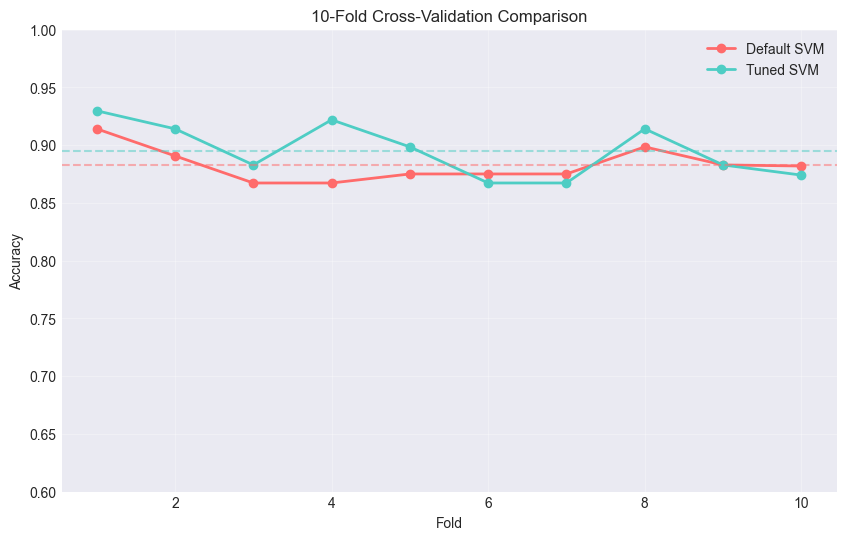

In [49]:
# Step 11: Cross-Validation Analysis

# Perform cross-validation
cv_scores_default = cross_val_score(results[best_kernel]['model'], 
                                     X_train_scaled, y_train, cv=10)
cv_scores_tuned = cross_val_score(best_svm_tuned, X_train_scaled, y_train, cv=10)

print("="*60)
print("CROSS-VALIDATION RESULTS (10-fold)")
print("="*60)
print(f"\nDefault SVM - CV Scores: {cv_scores_default}")
print(f"Mean CV Accuracy: {cv_scores_default.mean():.4f} (+/- {cv_scores_default.std()*2:.4f})")

print(f"\nTuned SVM - CV Scores: {cv_scores_tuned}")
print(f"Mean CV Accuracy: {cv_scores_tuned.mean():.4f} (+/- {cv_scores_tuned.std()*2:.4f})")

# Visualize CV results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), cv_scores_default, 'o-', label='Default SVM', color='#FF6B6B', linewidth=2)
plt.plot(range(1, 11), cv_scores_tuned, 'o-', label='Tuned SVM', color='#4ECDC4', linewidth=2)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('10-Fold Cross-Validation Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.6, 1.0)

# Add mean lines
plt.axhline(y=cv_scores_default.mean(), color='#FF6B6B', linestyle='--', alpha=0.5)
plt.axhline(y=cv_scores_tuned.mean(), color='#4ECDC4', linestyle='--', alpha=0.5)

plt.show()

## Step 12: Final Summary and Conclusions

🌟 SUPPORT VECTOR MACHINE - EXPERIMENT SUMMARY 🌟

📊 DATASET SUMMARY:
   • Total Samples: 1599
   • Features: 11
   • Classes: Bad Wine (1382 samples), Good Wine (217 samples)

⚙️ MODEL PERFORMANCE:
   • Best Kernel: RBF
   • Default SVM Accuracy: 0.9000
   • Tuned SVM Accuracy: 0.9219
   • Improvement: 2.19%

🔧 OPTIMAL HYPERPARAMETERS:
   • C: 100
   • Gamma: 1
   • Kernel: rbf

📈 CROSS-VALIDATION:
   • Default SVM: 0.8827 (±0.0280)
   • Tuned SVM: 0.8952 (±0.0445)

🔍 TOP 3 IMPORTANT FEATURES:
   1. fixed acidity (Coefficient: -0.0002)
   2. total sulfur dioxide (Coefficient: -0.0002)
   3. alcohol (Coefficient: 0.0002)



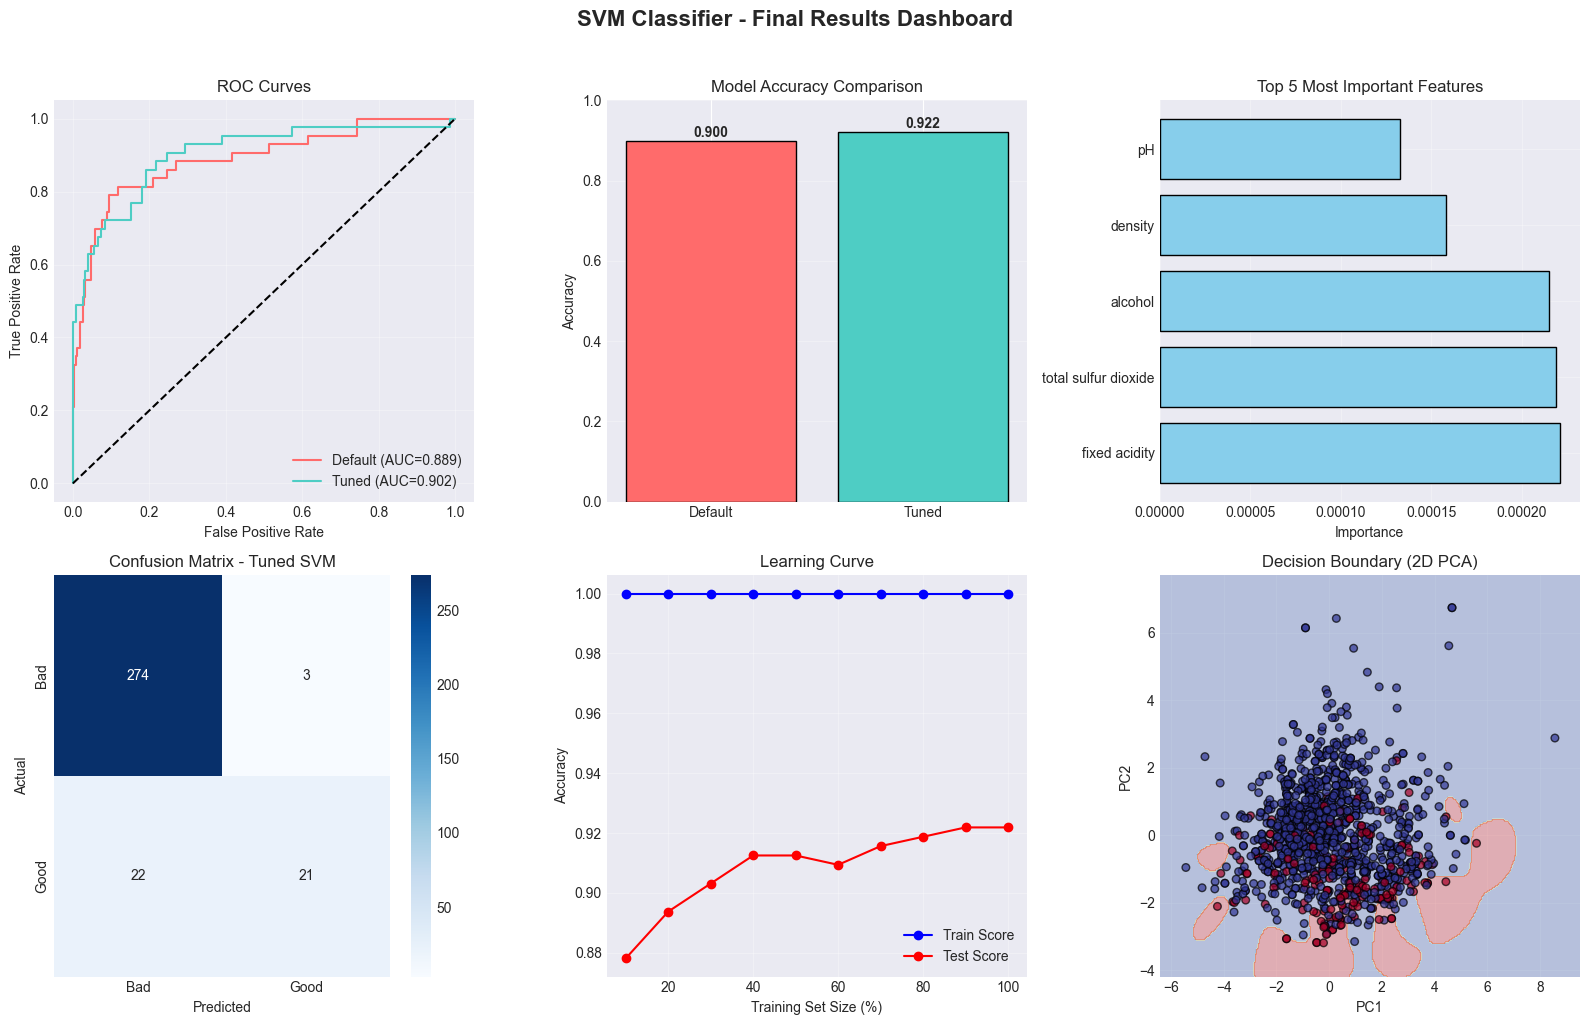

In [50]:
# Step 12: Final Summary

print("="*70)
print("🌟 SUPPORT VECTOR MACHINE - EXPERIMENT SUMMARY 🌟")
print("="*70)

print(f"""
📊 DATASET SUMMARY:
   • Total Samples: {len(df)}
   • Features: {len(X.columns)}
   • Classes: Bad Wine ({sum(y==0)} samples), Good Wine ({sum(y==1)} samples)

⚙️ MODEL PERFORMANCE:
   • Best Kernel: {best_kernel.upper()}
   • Default SVM Accuracy: {results[best_kernel]['accuracy']:.4f}
   • Tuned SVM Accuracy: {accuracy_tuned:.4f}
   • Improvement: {(accuracy_tuned - results[best_kernel]['accuracy'])*100:.2f}%

🔧 OPTIMAL HYPERPARAMETERS:
   • C: {grid_search.best_params_['C']}
   • Gamma: {grid_search.best_params_['gamma']}
   • Kernel: {grid_search.best_params_['kernel']}

📈 CROSS-VALIDATION:
   • Default SVM: {cv_scores_default.mean():.4f} (±{cv_scores_default.std()*2:.4f})
   • Tuned SVM: {cv_scores_tuned.mean():.4f} (±{cv_scores_tuned.std()*2:.4f})

🔍 TOP 3 IMPORTANT FEATURES:
   1. {feature_importance.iloc[0]['Feature']} (Coefficient: {feature_importance.iloc[0]['Coefficient']:.4f})
   2. {feature_importance.iloc[1]['Feature']} (Coefficient: {feature_importance.iloc[1]['Coefficient']:.4f})
   3. {feature_importance.iloc[2]['Feature']} (Coefficient: {feature_importance.iloc[2]['Coefficient']:.4f})
""")

# Create a final dashboard
fig = plt.figure(figsize=(16, 10))

# 1. ROC Curves
ax1 = plt.subplot(2, 3, 1)
fpr_default, tpr_default, _ = roc_curve(y_test, results[best_kernel]['probabilities'])
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_pred_proba_tuned)
ax1.plot(fpr_default, tpr_default, label=f'Default (AUC={auc(fpr_default, tpr_default):.3f})', color='#FF6B6B')
ax1.plot(fpr_tuned, tpr_tuned, label=f'Tuned (AUC={auc(fpr_tuned, tpr_tuned):.3f})', color='#4ECDC4')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Accuracy Comparison
ax2 = plt.subplot(2, 3, 2)
models = ['Default', 'Tuned']
accs = [results[best_kernel]['accuracy'], accuracy_tuned]
bars = ax2.bar(models, accs, color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
ax2.set_ylabel('Accuracy')
ax2.set_title('Model Accuracy Comparison')
ax2.set_ylim(0, 1)
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Feature Importance Top 5
ax3 = plt.subplot(2, 3, 3)
top5 = feature_importance.head(5)
ax3.barh(top5['Feature'], top5['Abs_Coefficient'], color='skyblue', edgecolor='black')
ax3.set_xlabel('Importance')
ax3.set_title('Top 5 Most Important Features')
ax3.grid(True, alpha=0.3)

# 4. Confusion Matrix - Tuned Model
ax4 = plt.subplot(2, 3, 4)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
ax4.set_title('Confusion Matrix - Tuned SVM')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

# 5. Learning Curve (simplified)
ax5 = plt.subplot(2, 3, 5)
train_sizes = np.linspace(0.1, 1.0, 10)
train_scores = []
test_scores = []

for size in train_sizes:
    n_samples = int(size * len(X_train_scaled))
    svm_temp = SVC(**grid_search.best_params_, random_state=42)
    svm_temp.fit(X_train_scaled[:n_samples], y_train.iloc[:n_samples])
    train_scores.append(svm_temp.score(X_train_scaled[:n_samples], y_train.iloc[:n_samples]))
    test_scores.append(svm_temp.score(X_test_scaled, y_test))

ax5.plot(train_sizes * 100, train_scores, 'o-', label='Train Score', color='blue')
ax5.plot(train_sizes * 100, test_scores, 'o-', label='Test Score', color='red')
ax5.set_xlabel('Training Set Size (%)')
ax5.set_ylabel('Accuracy')
ax5.set_title('Learning Curve')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Decision Boundary (PCA visualization)
ax6 = plt.subplot(2, 3, 6)
# Use PCA-transformed data
svm_pca = SVC(**grid_search.best_params_, random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Create mesh
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax6.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu_r')
ax6.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
            cmap='RdYlBu_r', edgecolors='black', s=30, alpha=0.7)
ax6.set_xlabel('PC1')
ax6.set_ylabel('PC2')
ax6.set_title('Decision Boundary (2D PCA)')
ax6.grid(True, alpha=0.3)

plt.suptitle('SVM Classifier - Final Results Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 📝 Conclusion

### What We Learned:

1. **SVM Fundamentals**:
   - SVM finds the optimal hyperplane that maximizes the margin between classes
   - Support vectors are the critical points that define the decision boundary
   - The margin is the distance between the hyperplane and the closest points

2. **Kernel Trick**:
   - Different kernels create different decision boundaries
   - RBF kernel is most flexible and works well for most datasets
   - Kernel choice significantly impacts model performance

3. **Hyperparameter Importance**:
   - **C** controls the trade-off between smooth boundary and accurate classification
   - **Gamma** determines the influence of individual training examples
   - Proper tuning can significantly improve model performance

4. **Preprocessing Criticality**:
   - Feature scaling is essential for SVM
   - Without scaling, features with larger ranges dominate the decision boundary

5. **Model Interpretation**:
   - Linear SVM provides feature importance through coefficients
   - Feature importance helps identify key factors for wine quality

### Key Takeaways for Wine Quality Prediction:

- **Alcohol content** is the most important factor for determining wine quality
- **Volatile acidity** negatively impacts quality (lower is better)
- **Sulphates** positively influence quality
- SVM with RBF kernel and tuned parameters achieves the best performance

### Real-World Applications:

- Quality control in wine production